In [51]:
# Sleep Quality Prediction based on Lifestyle Parameters

# Import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
import numpy as np

df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

# Split Blood Pressure into Systolic/Diastolic
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(float)


# Define Feature Set and Target
features = ['Physical Activity Level', 'Stress Level', 'BMI Category','Systolic', 'Diastolic', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']
X = df[features]
y = df['Quality of Sleep']

# Scale Numerics, Encode Categoricals
categorical = ['BMI Category', 'Sleep Disorder']
numerical = ['Physical Activity Level', 'Stress Level', 'Systolic', 'Diastolic', 'Heart Rate', 'Daily Steps']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
])

X_processed = preprocessor.fit_transform(X)

#after prprocessing
print('------------------------------------------------')
print(X.head())

# Split Data (Train/Test)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42,stratify=y)


# Random Forest Regressor (Predict Sleep Quality Score)
regressor = RandomForestRegressor(n_estimators=150, random_state=42)
regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)

# Evaluation for regression
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Regression Model Performance")
print("--------------------------------")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

# Converting Predicted Sleep Scores to Sleep Quality Categories
def categorize_sleep_quality(score):
    if score <= 5:
        return 'Low'
    elif 6 <= score <= 7:
        return 'Medium'
    else:
        return 'High'

predicted_category = [categorize_sleep_quality(x) for x in y_pred]
actual_category = [categorize_sleep_quality(x) for x in y_test]

print("\n Converted Regression Output to Categories")
print("---------------------------------------------")
cat_results = pd.DataFrame({'Actual': actual_category, 'Predicted': predicted_category})
print(cat_results.head())



# Random Forest Classifier (Predict Sleep Disorder)

# Fill NaN values in 'Sleep Disorder' column with "None"
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

X_disorder = df.drop(columns=['Sleep Disorder', 'Quality of Sleep', 'Person ID', 'Blood Pressure'], errors='ignore')
y_disorder = df['Sleep Disorder']

# OneHotEncode categorical and scale numeric
categorical_d = ['BMI Category', 'Occupation', 'Gender']
numerical_d = ['Age', 'Physical Activity Level', 'Stress Level', 'Systolic', 'Diastolic', 'Heart Rate', 'Daily Steps']

preprocessor_disorder = ColumnTransformer([
    ('num', StandardScaler(), numerical_d),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_d)
])

X_disorder_processed = preprocessor_disorder.fit_transform(X_disorder)

# Train/test split for sleep disorder classification
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_disorder_processed, y_disorder, test_size=0.2, random_state=42)

classifier = RandomForestClassifier(n_estimators=200, random_state=42)
classifier.fit(X_train_d, y_train_d)

y_pred_d = classifier.predict(X_test_d)

# Evaluation for classification
print("\n Sleep Disorder Classification Performance")
print("---------------------------------------------")
print(f"Accuracy: {accuracy_score(y_test_d, y_pred_d):.2f}")
print("\nClassification Report:")
print(classification_report(y_test_d, y_pred_d))


------------------------------------------------
   Physical Activity Level  Stress Level BMI Category  Systolic  Diastolic  \
0                       42             6   Overweight     126.0       83.0   
1                       60             8       Normal     125.0       80.0   
2                       60             8       Normal     125.0       80.0   
3                       30             8        Obese     140.0       90.0   
4                       30             8        Obese     140.0       90.0   

   Heart Rate  Daily Steps Sleep Disorder  
0          77         4200            NaN  
1          75        10000            NaN  
2          75        10000            NaN  
3          85         3000    Sleep Apnea  
4          85         3000    Sleep Apnea  
Regression Model Performance
--------------------------------
Mean Squared Error: 0.06
R² Score: 0.95

 Converted Regression Output to Categories
---------------------------------------------
   Actual Predicted
0    H

MAE: 0.08885589891203036
RMSE: 0.2520454761164309
R2 Score: 0.9543278455492056


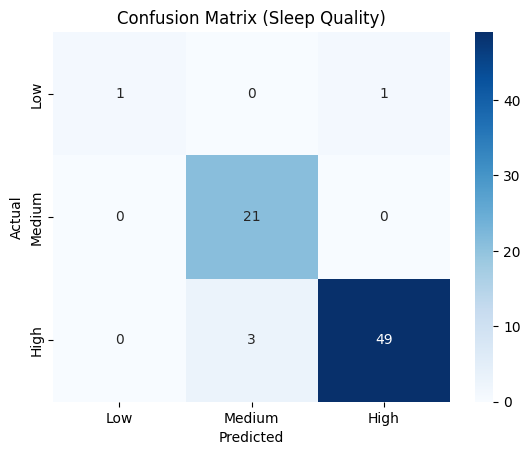


Classification Report:
              precision    recall  f1-score   support

        High      0.980     0.942     0.961        52
         Low      1.000     0.500     0.667         2
      Medium      0.875     1.000     0.933        21

    accuracy                          0.947        75
   macro avg      0.952     0.814     0.854        75
weighted avg      0.951     0.947     0.945        75

Accuracy: 0.9466666666666667


In [50]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_reg = regressor.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred_reg))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_reg)))
print("R2 Score:", r2_score(y_test, y_pred_reg))

# Convert regression output to categories
def categorize_sleep_quality(value):
    if value <=5:
        return "Low"
    elif 6 <= value < 7:
        return "Medium"
    else:
        return "High"

y_test_cat = [categorize_sleep_quality(v) for v in y_test]
y_pred_cat = [categorize_sleep_quality(v) for v in y_pred_reg]

# Confusion Matrix
cm = confusion_matrix(y_test_cat, y_pred_cat, labels=["Low", "Medium", "High"])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.title("Confusion Matrix (Sleep Quality)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Metrics
print("\nClassification Report:")
print(classification_report(y_test_cat, y_pred_cat, digits=3))

print("Accuracy:", accuracy_score(y_test_cat, y_pred_cat))


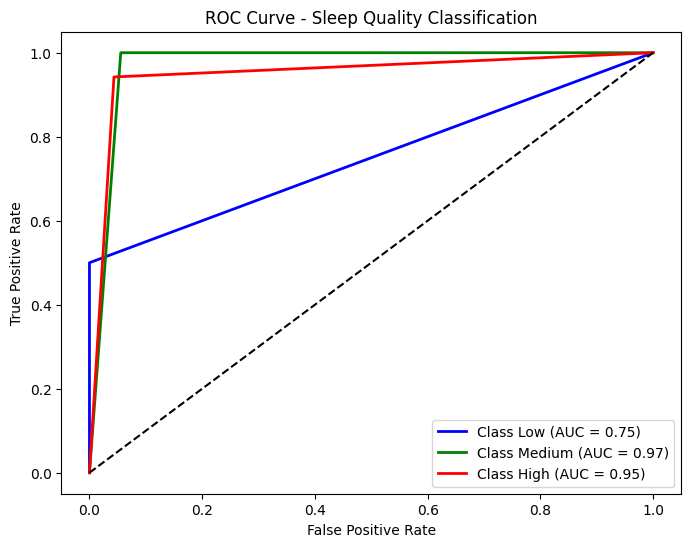

In [52]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Convert categorical labels to numeric for ROC/AUC
y_test_bin = label_binarize(y_test_cat, classes=["Low", "Medium", "High"])
y_pred_bin = label_binarize(y_pred_cat, classes=["Low", "Medium", "High"])

# Plot ROC Curve
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(y_test_bin.shape[1]):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))
for i, color in zip(range(y_test_bin.shape[1]), ['blue', 'green', 'red']):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {["Low","Medium","High"][i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Sleep Quality Classification")
plt.legend()
plt.show()


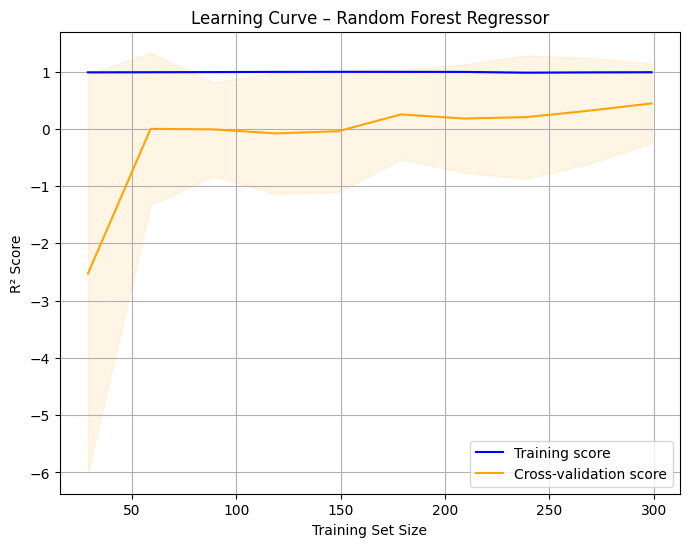

In [42]:
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Define model
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)

# Generate learning curve data

train_sizes, train_scores, test_scores = learning_curve(
    rf_reg, X_processed, y, cv=5, scoring=make_scorer(r2_score),
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

# Compute mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label="Training score", color="blue")
plt.plot(train_sizes, test_mean, label="Cross-validation score", color="orange")

plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, color="blue", alpha=0.1)
plt.fill_between(train_sizes, test_mean-test_std, test_mean+test_std, color="orange", alpha=0.1)

plt.title("Learning Curve – Random Forest Regressor")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)
plt.show()


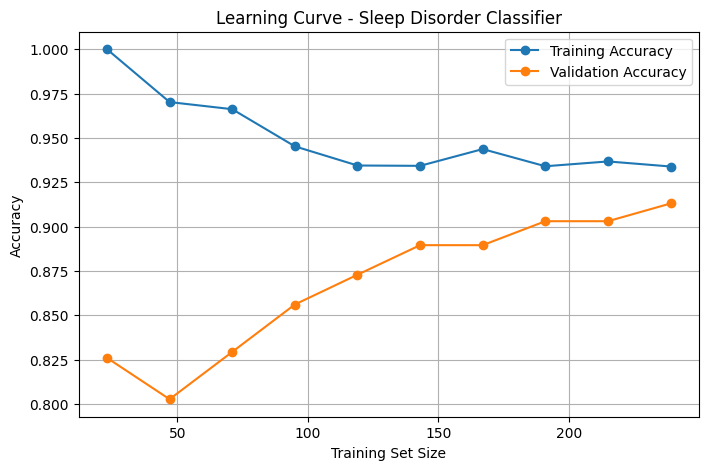

In [40]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    classifier, X_train_d, y_train_d, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, 'o-', label="Training Accuracy")
plt.plot(train_sizes, test_mean, 'o-', label="Validation Accuracy")
plt.title("Learning Curve - Sleep Disorder Classifier")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


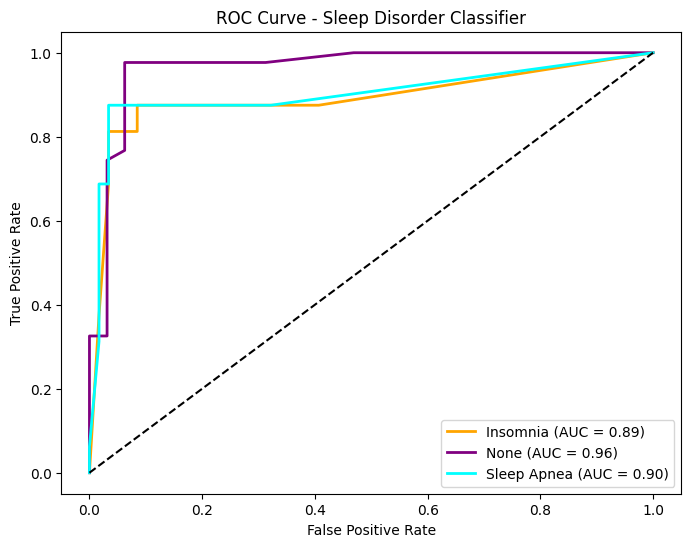

In [53]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import LabelEncoder

# Binarize output
lb = LabelEncoder()
y_test_d_num = lb.fit_transform(y_test_d)
y_score_d = classifier.predict_proba(X_test_d)

# For multi-class ROC
y_test_bin_d = label_binarize(y_test_d_num, classes=range(len(lb.classes_)))

fpr_d = dict()
tpr_d = dict()
roc_auc_d = dict()

for i in range(y_test_bin_d.shape[1]):
    fpr_d[i], tpr_d[i], _ = roc_curve(y_test_bin_d[:, i], y_score_d[:, i])
    roc_auc_d[i] = auc(fpr_d[i], tpr_d[i])

plt.figure(figsize=(8,6))
for i, color in zip(range(y_test_bin_d.shape[1]), ['orange', 'purple', 'cyan', 'green']):
    plt.plot(fpr_d[i], tpr_d[i], color=color, lw=2,
             label=f'{lb.classes_[i]} (AUC = {roc_auc_d[i]:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Sleep Disorder Classifier")
plt.legend()
plt.show()
